In [ ]:
# Install required packages
!pip install --upgrade --quiet 'natural-pdf[all]>=0.5.0'

print('✓ Packages installed!')

**Slides:** [slides.pdf](./slides.pdf)

In [1]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/Atlanta_Public_Schools_GA_sample.pdf")
pdf

<PDF source='https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/Atlanta_Public_Schools_GA_sample.pdf' pages=5>

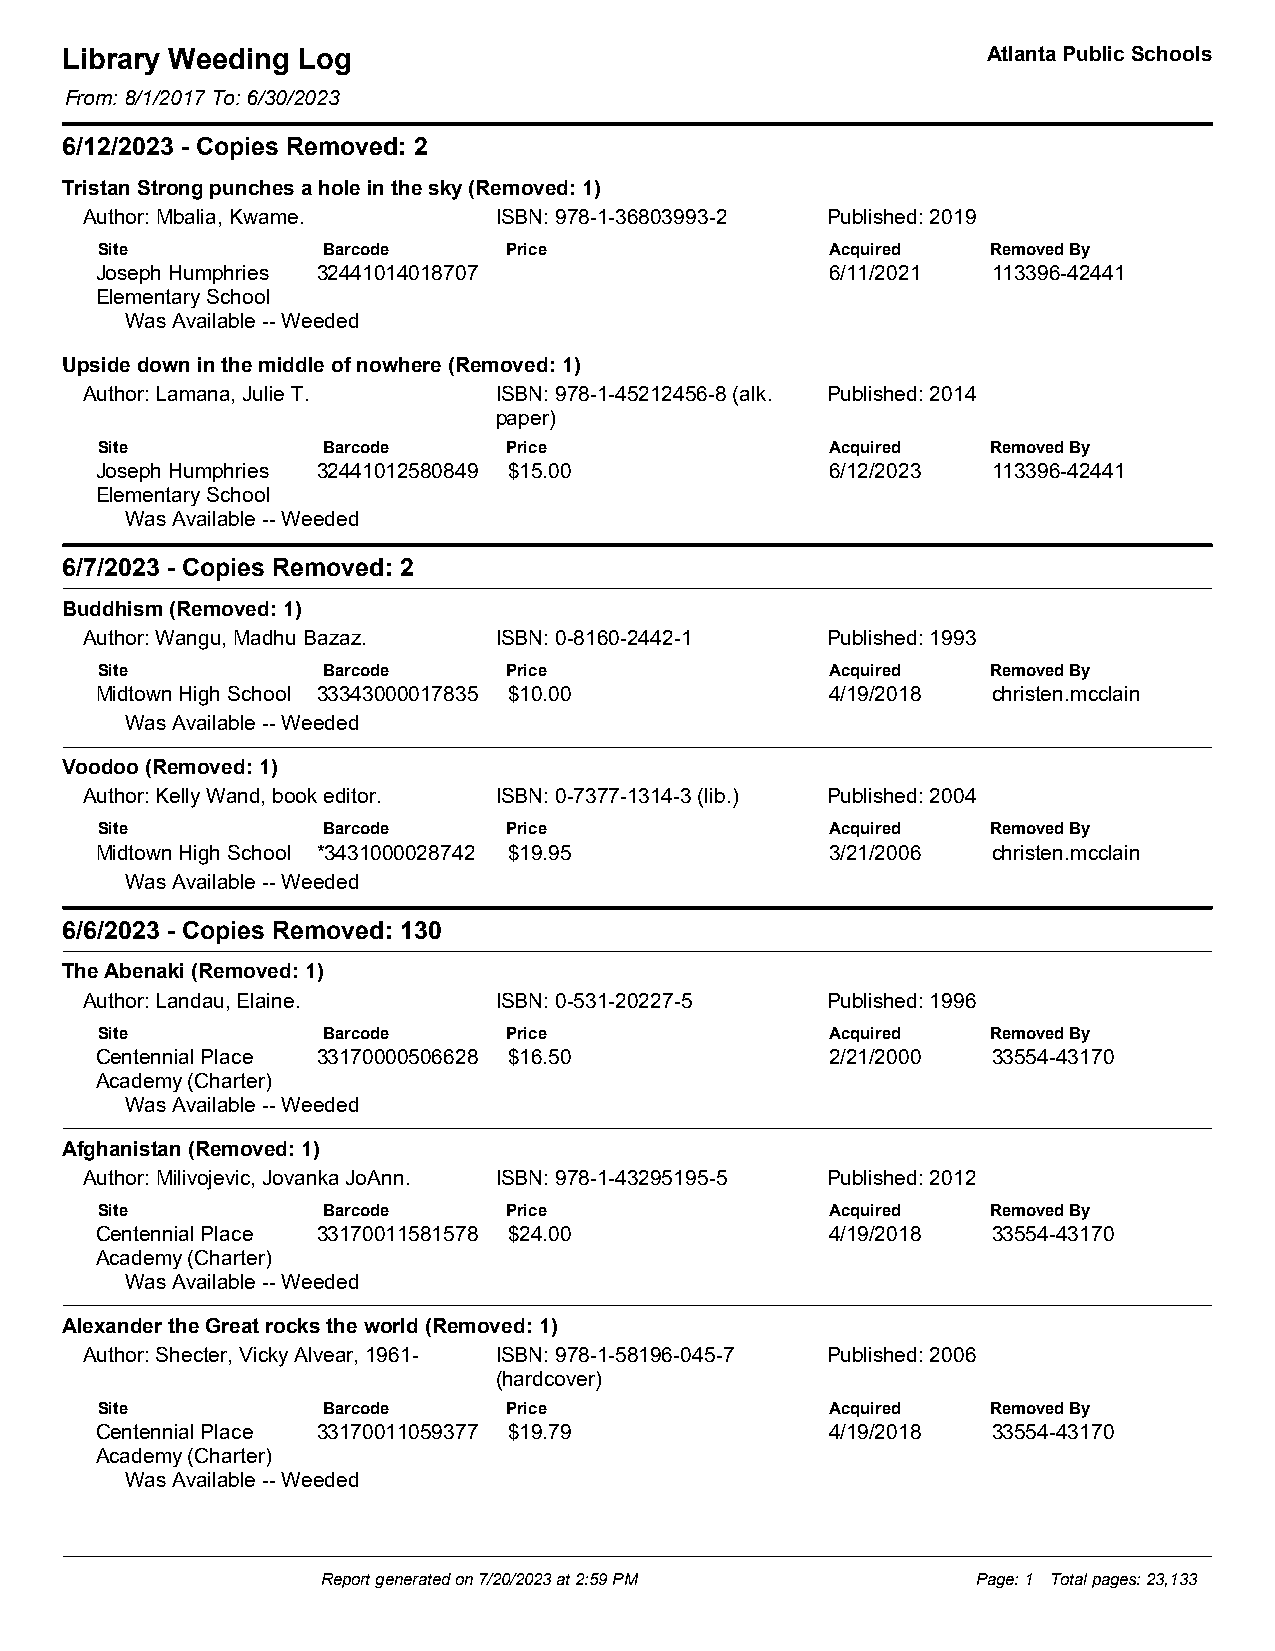

In [2]:
page = pdf.pages[0]
page.show()

We'll add two **exclusion zones** because we aren't interested in the top and bottom of the pages.

In [3]:
pdf.add_exclusion(lambda page: page.find('line[width>=2]').above())
pdf.add_exclusion(lambda page: page.find_all('line')[-1].below())

<PDF source='https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/Atlanta_Public_Schools_GA_sample.pdf' pages=5>

In [4]:
page.find_all('text').inspect()

text,x0,top,x1,bottom,font_family,font_variant,size,styles,source,confidence,color
6/12/2023 - Copies Removed: 2,30,65,205,77,font000000002a8d158a,AAAAAB,12,,native,1.00,#000000
Tristan Strong punches a hole in the sky (Removed:...,30,86,289,96,font000000002a8d158a,AAAAAB,10,,native,1.00,#000000
"Author: Mbalia, Kwame.",40,100,146,110,font000000002a8d158a,AAAAAD,10,,native,1.00,#000000
ISBN: 978-1-36803993-2,238,100,349,110,font000000002a8d158a,AAAAAD,10,,native,1.00,#000000
Published: 2019,397,100,469,110,font000000002a8d158a,AAAAAD,10,,native,1.00,#000000
Site,47,116,62,124,font000000002a8d158a,AAAAAB,8,,native,1.00,#000000
Barcode,155,116,187,124,font000000002a8d158a,AAAAAB,8,highlight(#ffffff),native,1.00,#000000
Price,243,116,263,124,font000000002a8d158a,AAAAAB,8,highlight(#ffffff),native,1.00,#000000
Acquired,398,116,433,124,font000000002a8d158a,AAAAAB,8,highlight(#ffffff),native,1.00,#000000
Removed By,475,116,523,124,font000000002a8d158a,AAAAAB,8,highlight(#ffffff),native,1.00,#000000


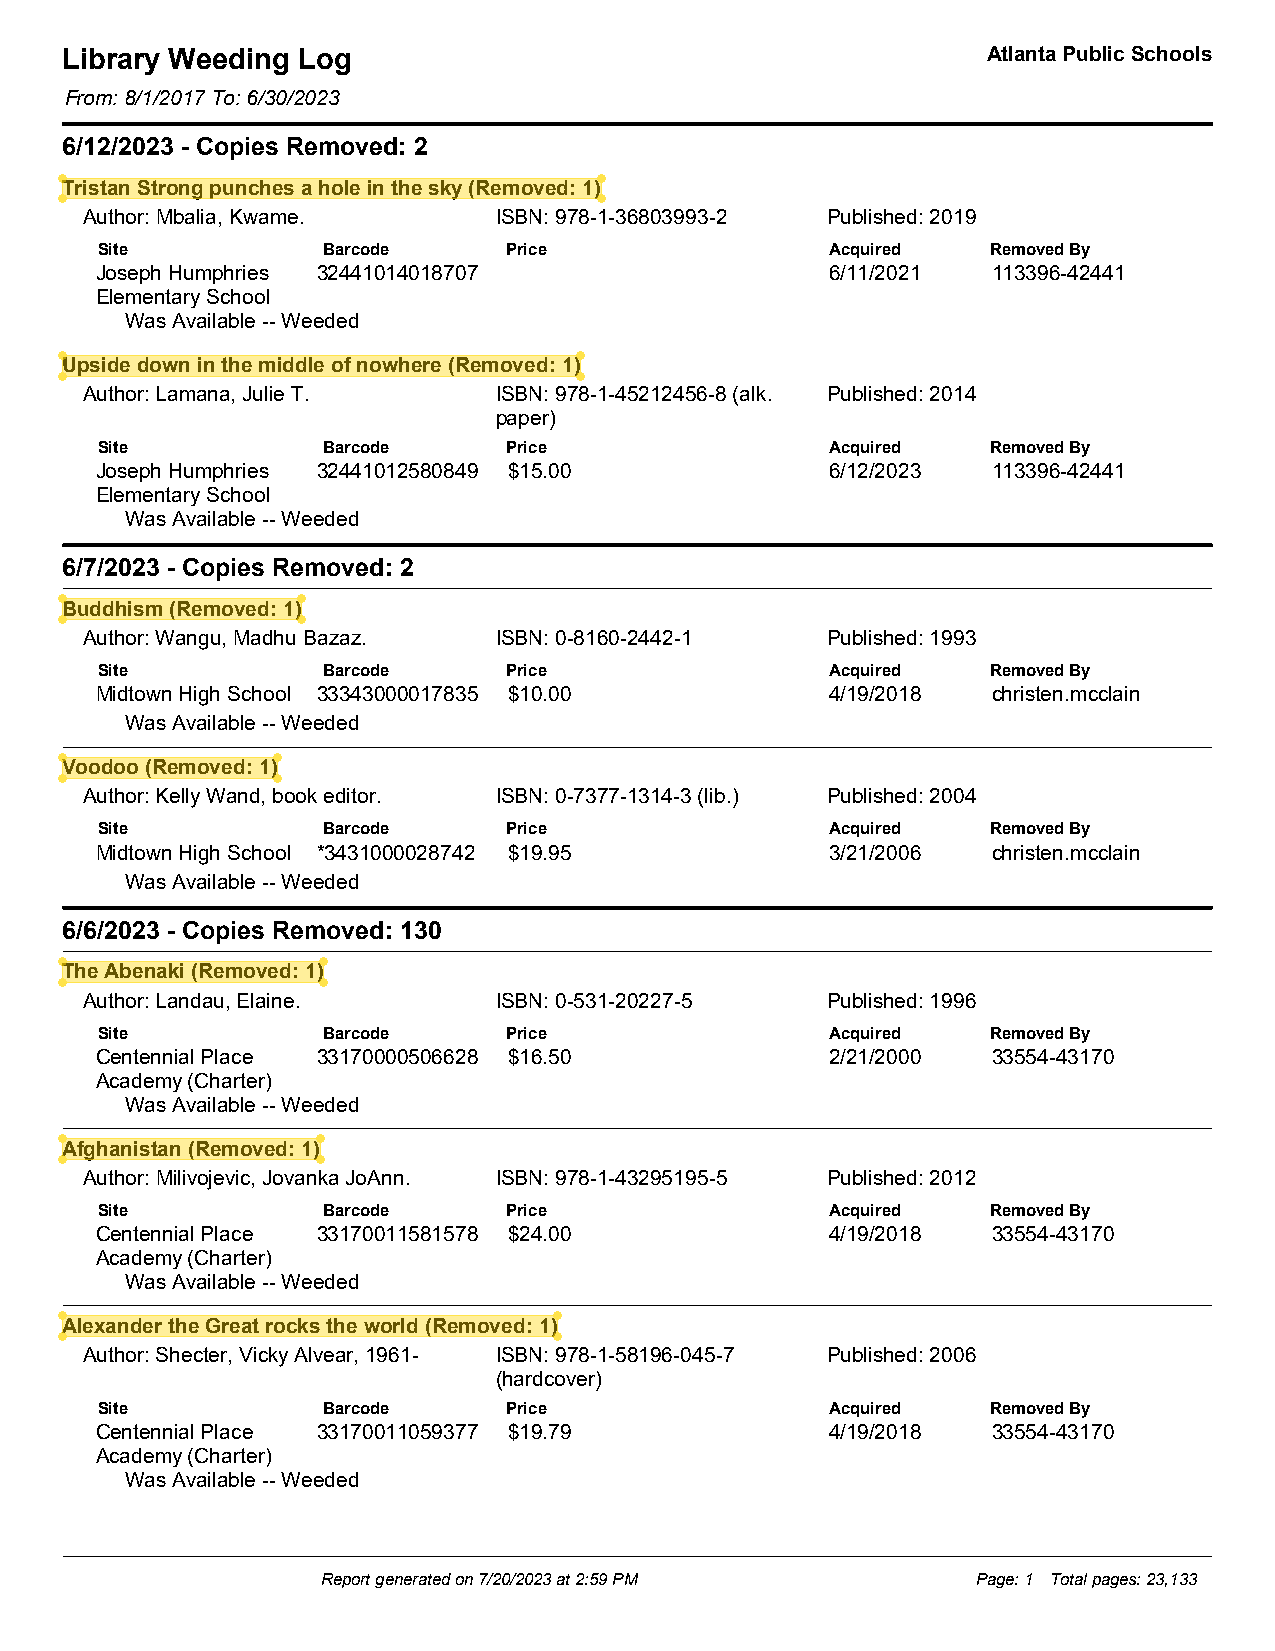

In [5]:
titles = page.find_all('text[font_variant=AAAAAB][size=10]')
titles.show()

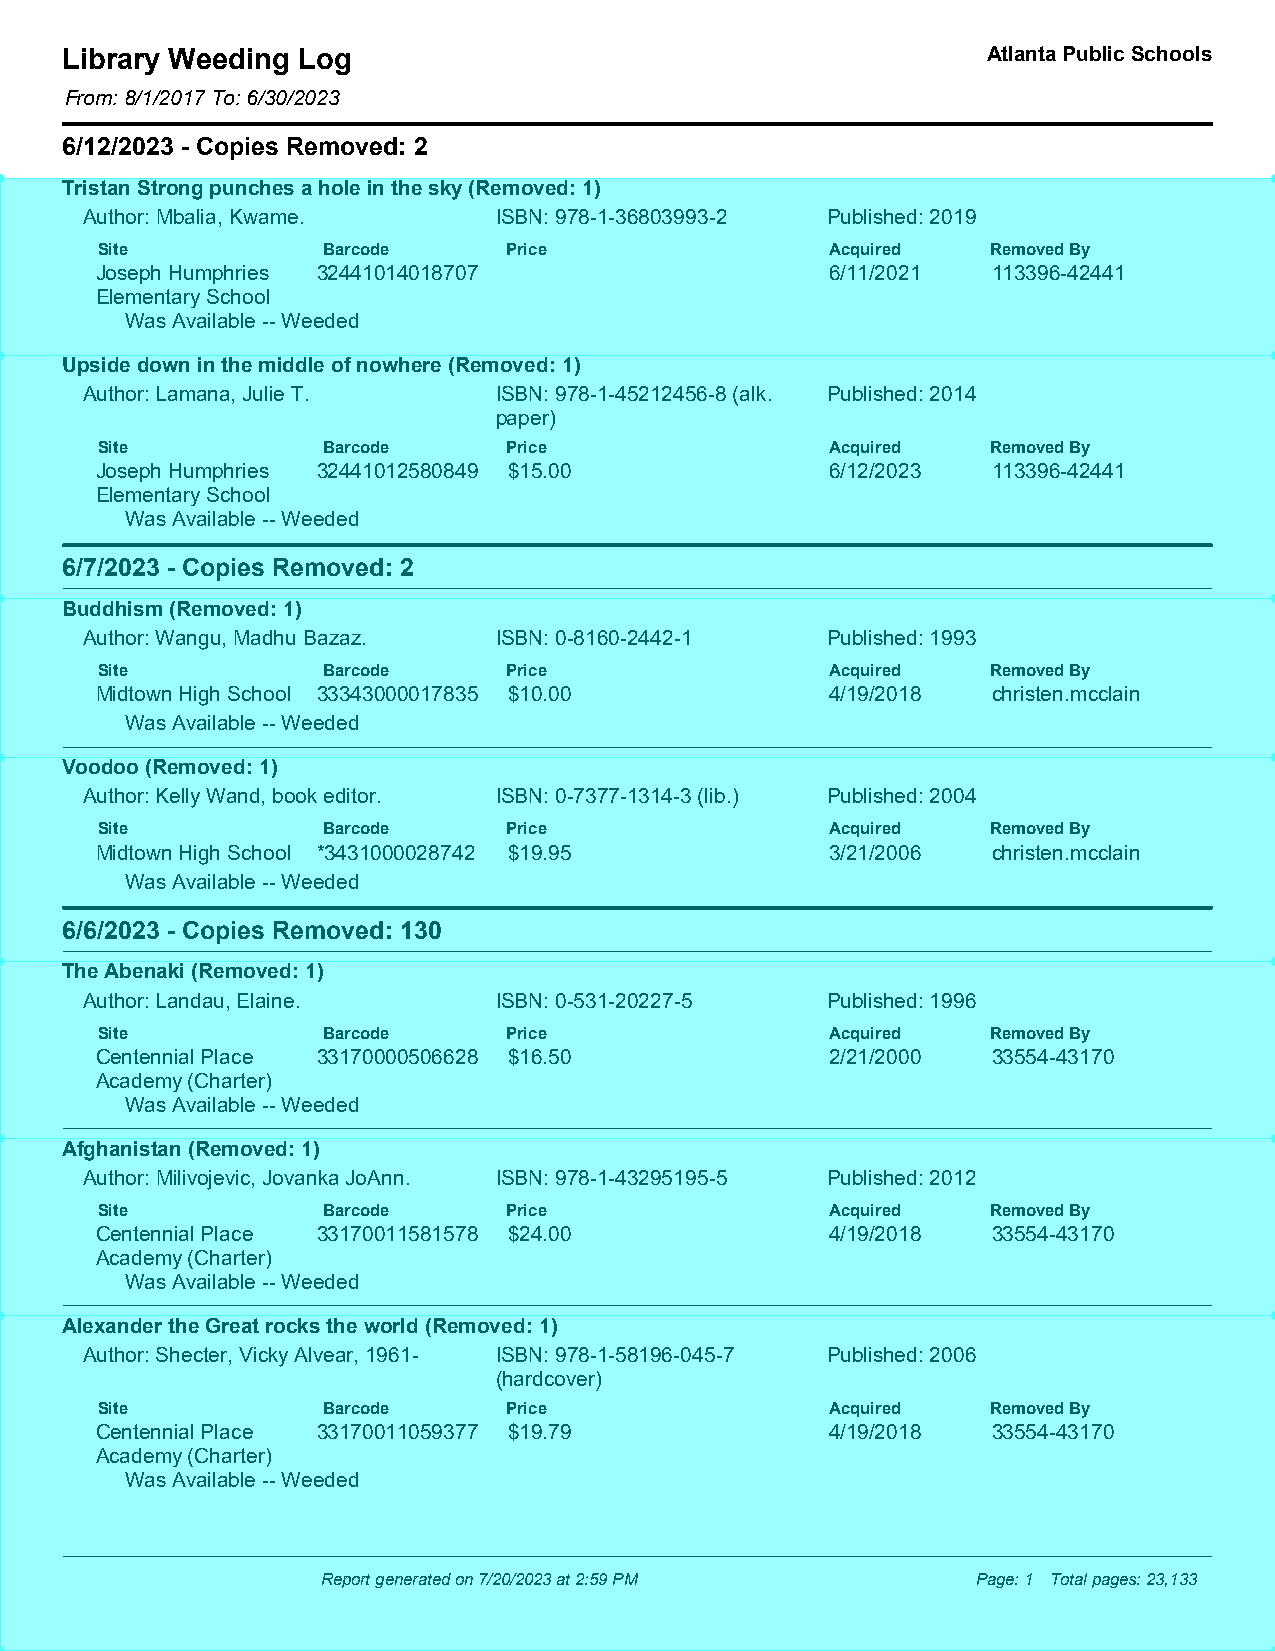

In [6]:
books = titles.below(until='text[font_variant=AAAAAB][size=10]',
                     include_endpoint=False,
                     include_source=True)
books.show()

In [7]:
books.find('text:contains(Site)').below().clip(books).find_all('text[x0<47][size=10]')

<ElementCollection[TextElement](count=12)>

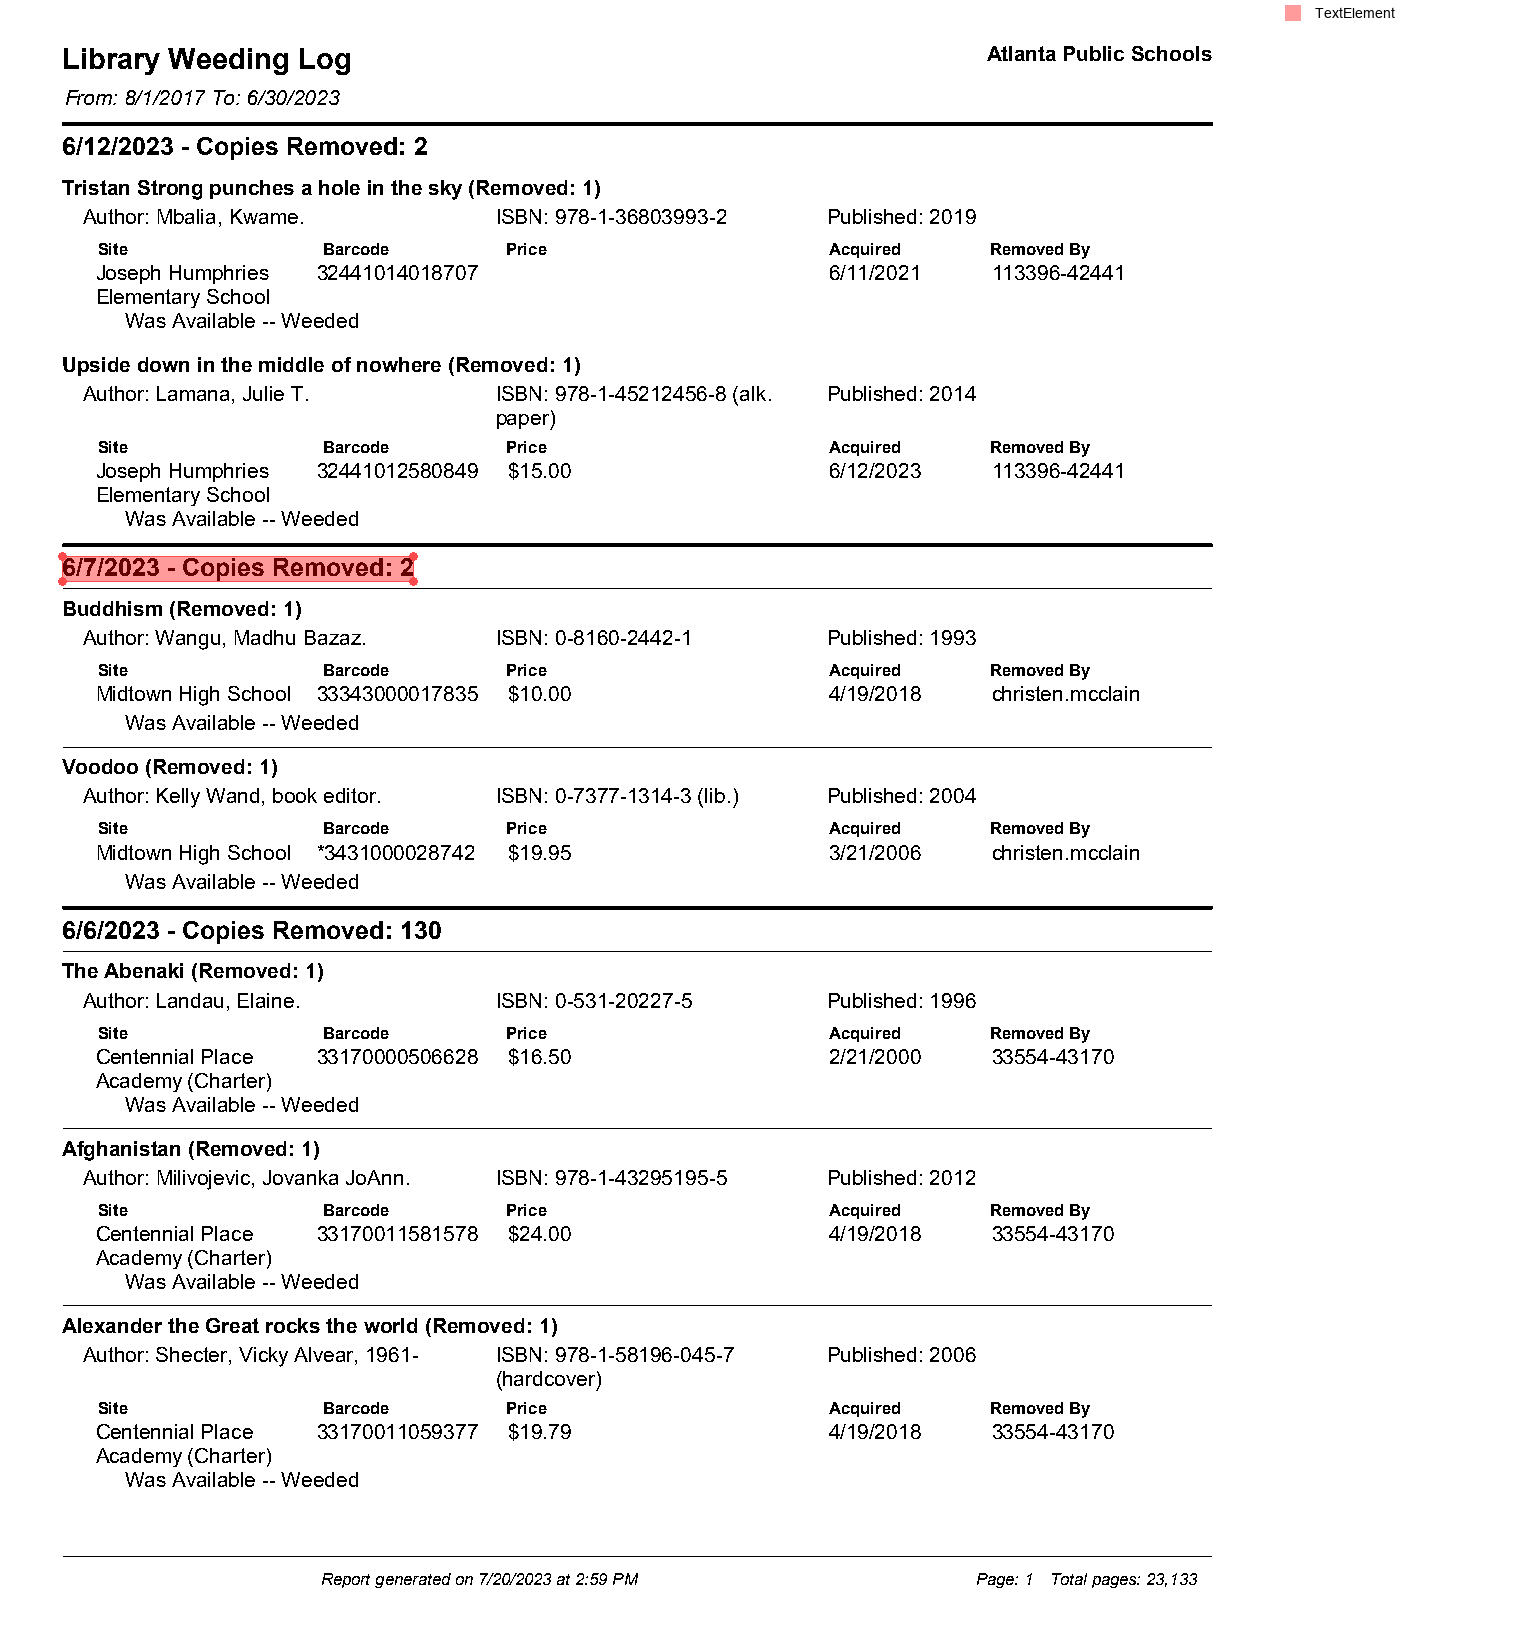

In [8]:
books[3].above(until='text[size>10]').endpoint.show()

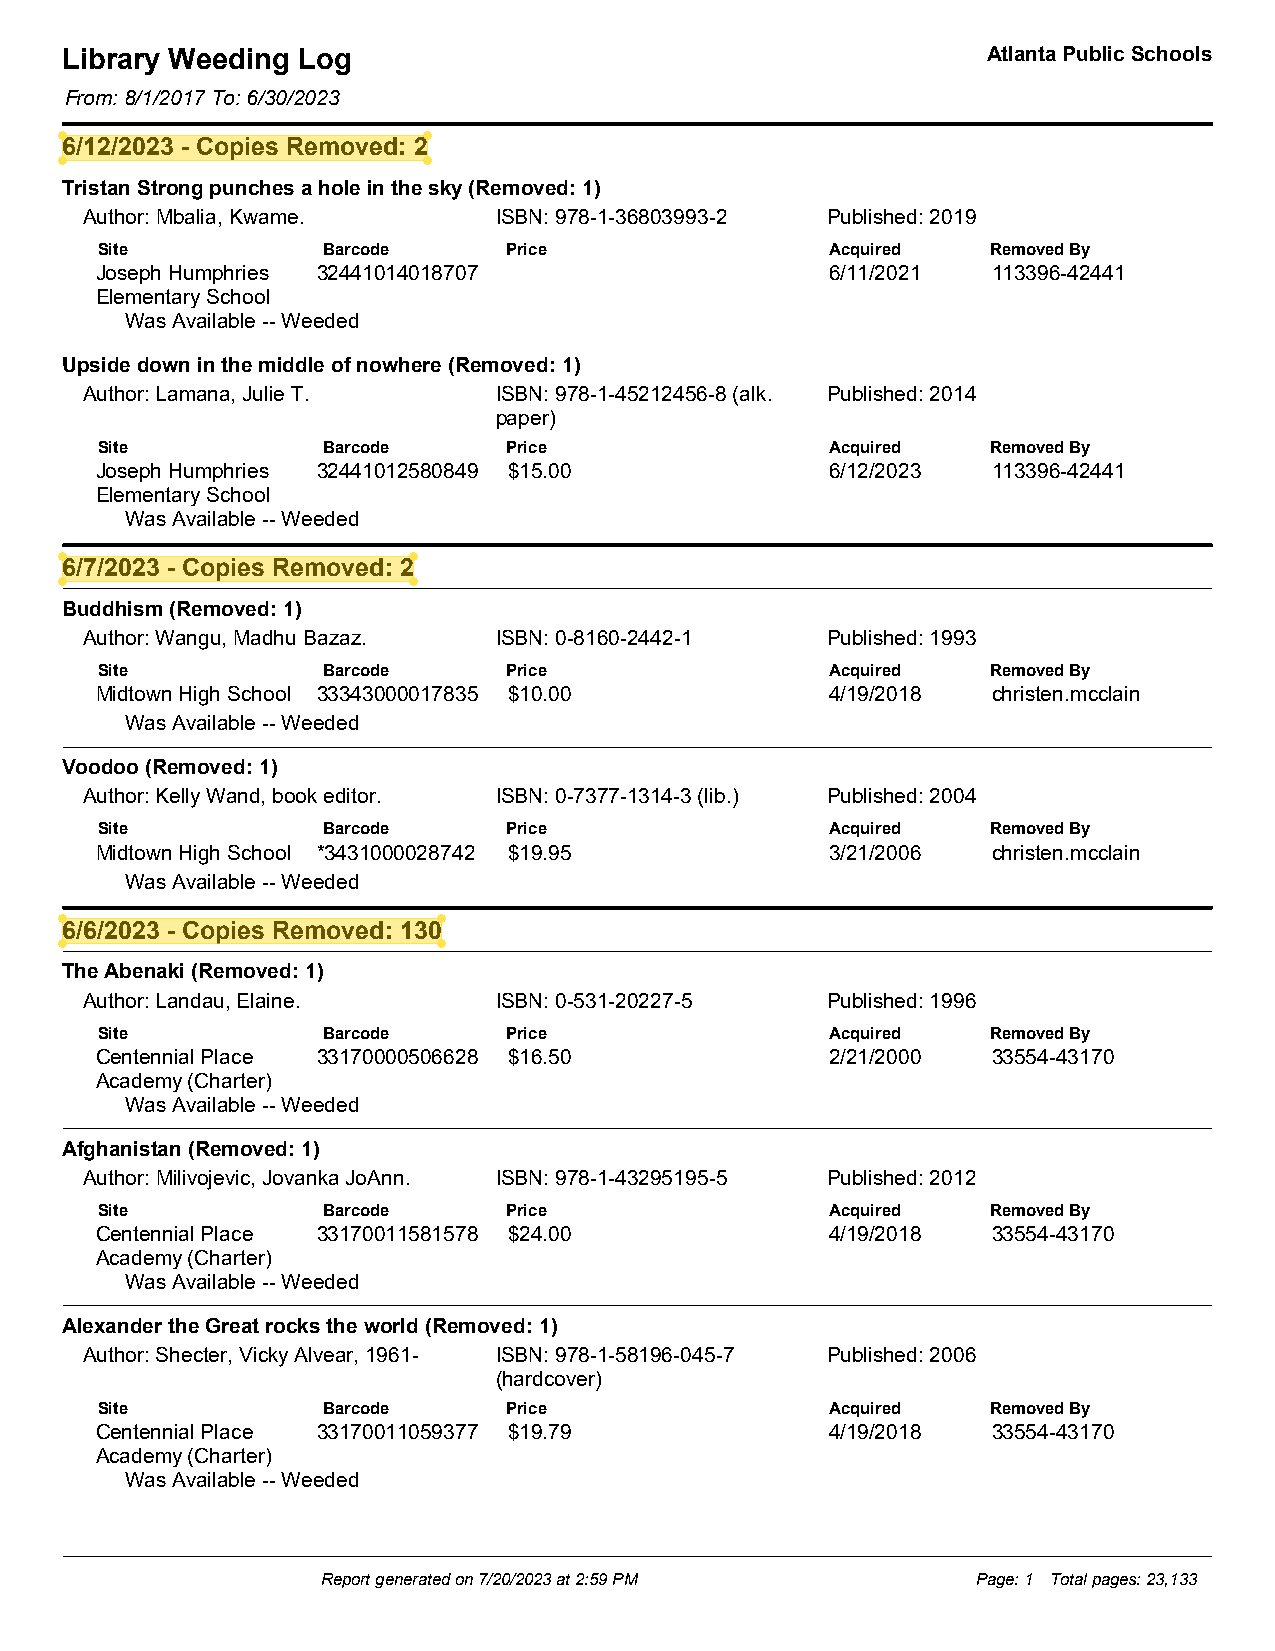

In [9]:
books.above(until='text[size>10]').endpoints.show()

In [10]:
import pandas as pd

df = pd.DataFrame({
    'author': books.find('text:contains(Author)').extract_each_text(),
    'isbn': books.find('text:contains(ISBN)').extract_each_text(),
    'published': books.find('text:contains(Published)').extract_each_text(),
    'site': books.find('text:contains(Site)').below().clip(books).apply(lambda area: area.find_all('text[x0<47][size=10]').extract_text()),
    'barcode': books.find('text:contains(Barcode)').below(width='element', height=12).expand(right=50).extract_each_text(),
    'price': books.find('text:contains(Price)').below(width='element', height=12).expand(right=50).extract_each_text(),
    'acquired': books.find('text:contains(Acquired)').below(width='element', height=12).expand(right=10).extract_each_text(),
    'removed_by': books.find('text:contains(Removed By)').below(width='element', height=12).expand(right=40).extract_each_text(),
    'date_removed': books.above(until='text[size>10]').endpoints.extract_each_text()
})
df

,author,isbn,published,site,barcode,price,acquired,removed_by,date_removed
0,"Author: Mbalia, Kwame.",ISBN: 978-1-36803993-2,Published: 2019,Joseph Humphries Elementary School,2441014018707,,6/11/2021,113396-42441,6/12/2023 - Copies Removed: 2
1,"Author: Lamana, Julie T.",ISBN: 978-1-45212456-8 (alk.,Published: 2014,Joseph Humphries Elementary School,2441012580849,$15.00,6/12/2023,113396-42441,6/12/2023 - Copies Removed: 2
2,"Author: Wangu, Madhu Bazaz.",ISBN: 0-8160-2442-1,Published: 1993,Midtown High School,3343000017835,$10.00,4/19/2018,christen.mcclain,6/7/2023 - Copies Removed: 2
3,"Author: Kelly Wand, book editor.",ISBN: 0-7377-1314-3 (lib.),Published: 2004,Midtown High School,3431000028742,$19.95,3/21/2006,christen.mcclain,6/7/2023 - Copies Removed: 2
4,"Author: Landau, Elaine.",ISBN: 0-531-20227-5,Published: 1996,Centennial Place Academy (Charter),3170000506628,$16.50,2/21/2000,33554-43170,6/6/2023 - Copies Removed: 130
5,"Author: Milivojevic, Jovanka JoAnn.",ISBN: 978-1-43295195-5,Published: 2012,Centennial Place Academy (Charter),3170011581578,$24.00,4/19/2018,33554-43170,6/6/2023 - Copies Removed: 130
6,"Author: Shecter, Vicky Alvear, 1961-",ISBN: 978-1-58196-045-7,Published: 2006,Centennial Place Academy (Charter),3170011059377,$19.79,4/19/2018,33554-43170,6/6/2023 - Copies Removed: 130


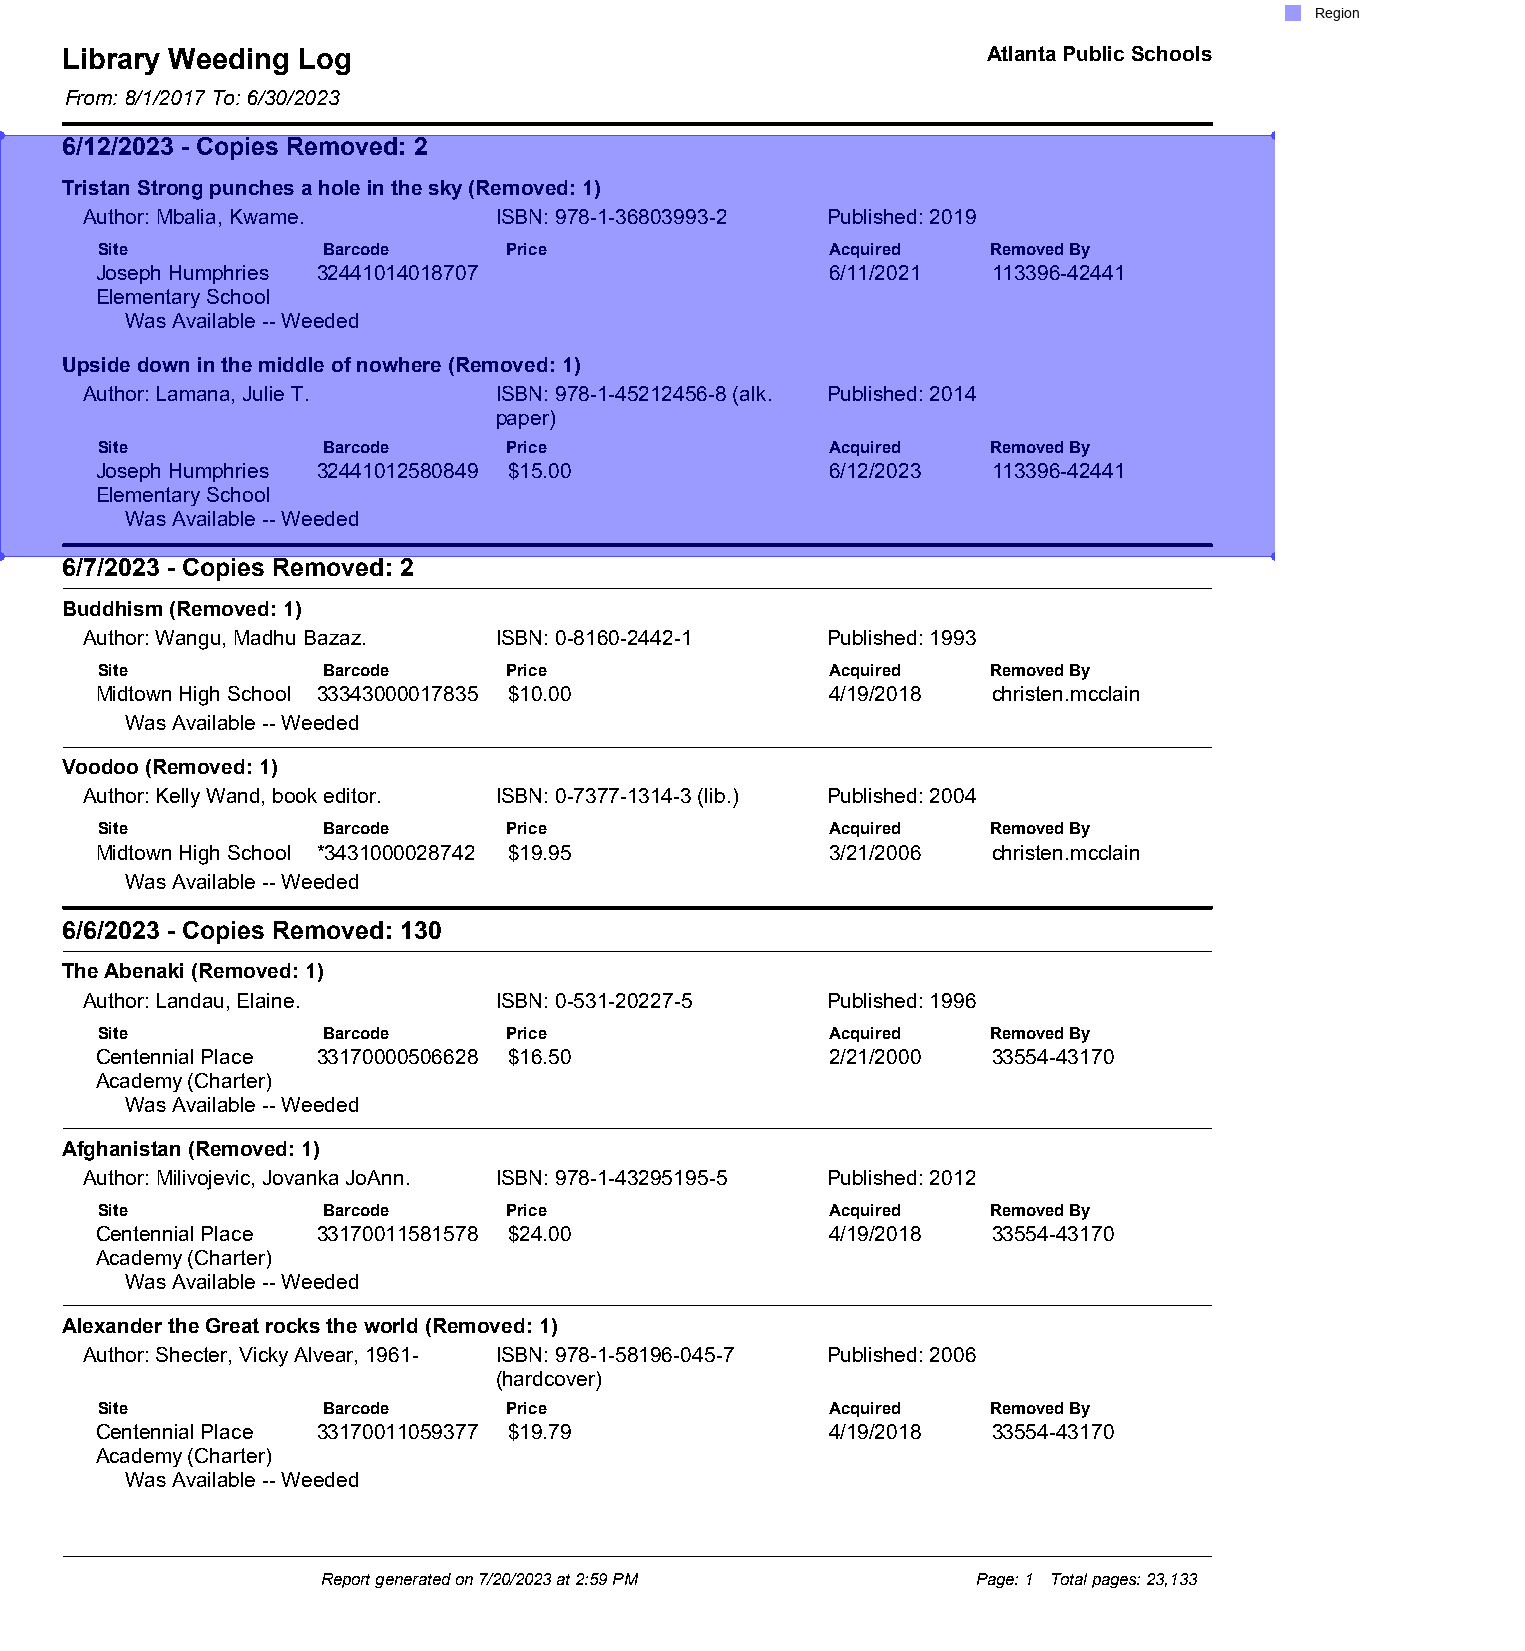

In [11]:
#page.find_all('text[size>10]').show()
sections = page.get_sections('text[size>10]')

sections[0].show()